# Annual EDA: Economic Freedom + Macro Panel (2000-Present)

**Focus**: Annual-frequency analysis of the EFW dataset merged with World Bank macro indicators.

This notebook avoids mixed-frequency bias by focusing on the annual EFW era (2000+).

**Key outputs**:
- Sample definition dashboard
- Time trends (EFW + macro)
- Correlations and scatter plots
- Within-country changes
- Outlier/extreme regime tables

## 0. Configuration

In [1]:
import sys
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

%matplotlib inline

# warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from src import downloaders, harmonize, merge_efw, quality, plots

# Configuration
EFW_PATH = "data/fraser.xlsx"
START_YEAR = 2000  # Annual EFW era

# Core macro variables for analysis (filled series where possible)
CORE_MACRO = [
    'gdppc_filled',
    'NY.GDP.MKTP.KD.ZG',
    'FP.CPI.TOTL.ZG',
    'trade_openness_filled',
    'investment_gfcf_filled',
    'govt_consumption_filled',
]

# Additional macro series for richer diagnostics
EXTENDED_MACRO = [
    'SP.POP.TOTL',
    'SL.UEM.TOTL.ZS',
    'FS.AST.PRVT.GD.ZS',
    'BX.KLT.DINV.WD.GD.ZS',
    'BN.CAB.XOKA.GD.ZS',
    'GC.TAX.TOTL.GD.ZS',
    'GC.DOD.TOTL.GD.ZS',
    'FM.LBL.BMNY.GD.ZS',
    'kaopen',
    'kof_globalization',
    'wgi_control_corruption',
    'wgi_govt_effectiveness',
    'wgi_political_stability',
    'wgi_regulatory_quality',
    'wgi_rule_of_law',
    'wgi_voice_accountability',
    'gdppc_pwt_scaled',
    'trade_openness_pwt',
    'investment_share_pwt',
    'govt_consumption_share_pwt',
    'human_capital',
    'SE.SEC.ENRR',        # School enrollment, secondary
    'SI.POV.GINI',        # Gini index
    'SP.DYN.LE00.IN',     # Life expectancy
    'NY.GDP.TOTL.RT.ZS',  # Natural resources rents
    'SL.TLF.CACT.ZS',     # Labor force participation
    'gdppc_maddison',     # Maddison Project GDP
    'years_schooling',    # Barro-Lee Years of Schooling
]

ANALYSIS_MACRO = CORE_MACRO + EXTENDED_MACRO

# Output directories
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

plots.setup_plot_style()
print("Configuration loaded.")
print(f"Analysis period: {START_YEAR}-present")

Configuration loaded.
Analysis period: 2000-present


## 1. Data Loading
### 1.1 Download Macro Data (WDI + secondary sources)

In [2]:
# Download macro data (cached)
print("=" * 60)
print("STEP 1: DOWNLOAD MACRO DATA")
print("=" * 60)

df_macro_long = downloaders.download_all_sources(
    force_download=False,
    include_secondary=True,
    verbose=True
)

STEP 1: DOWNLOAD MACRO DATA
Loading WDI from cache: data/raw/wdi_data.parquet


### 1.2 Load EFW Data

In [3]:
# Load EFW data
print("\n" + "=" * 60)
print("STEP 2: LOAD EFW DATA")
print("=" * 60)

df_efw = merge_efw.load_efw(EFW_PATH, verbose=True)

# Filter to annual era
df_efw_annual = merge_efw.get_efw_annual(df_efw, start_year=START_YEAR)
print(f"\nAnnual EFW (>= {START_YEAR}): {len(df_efw_annual):,} obs")


STEP 2: LOAD EFW DATA


Loaded Fraser EFW data:
  Observations: 4,950
  Years: 1970–2023
  Countries: 165
Loaded EFW: 4,950 obs, 165 countries

Annual EFW (>= 2000): 3,960 obs


## 2. Data Harmonization
### 2.1 Build ISO3 Concordance

In [4]:
print("\n" + "=" * 60)
print("STEP 3: HARMONIZE DATA")
print("=" * 60)

# Build concordance
name_to_iso3, concordance_df = harmonize.build_iso3_concordance(
    df_efw, 
    efw_iso_col='iso3',  # Already renamed
    efw_name_col='Countries',
    verbose=True
)

# Save concordance
harmonize.save_concordance(concordance_df)


STEP 3: HARMONIZE DATA
ISO3 Concordance built:
  Mapped names: 208
  From EFW: 38
  Manual overrides: 170
Saved concordance to data/intermediate/iso3_concordance.csv


### 2.2 Standardize and Reshape Macro Data

In [5]:
# Apply concordance for non-ISO3 labels before standardization
df_macro_long['iso3'] = df_macro_long['iso3'].astype(str).str.strip()
df_macro_long['iso3'] = df_macro_long['iso3'].map(name_to_iso3).fillna(df_macro_long['iso3'])

# Standardize ISO3 codes in macro data
df_macro_clean = harmonize.standardize_iso3(df_macro_long, verbose=True)

# Filter to annual period
df_macro_annual = df_macro_clean[df_macro_clean['year'] >= START_YEAR].copy()
print(f"Macro annual (>= {START_YEAR}): {len(df_macro_annual):,} obs")

# Reshape to wide
df_macro_wide = harmonize.long_to_wide(df_macro_annual, verbose=True)

def _to_pct(series):
    if series is None:
        return None
    non_na = series.dropna()
    if non_na.empty:
        return series
    if non_na.median() <= 1.5:
        return series * 100.0
    return series

def _coalesce(primary, fallback):
    if primary is None:
        return fallback
    if fallback is None:
        return primary
    return primary.fillna(fallback)

# PWT-derived series to improve coverage
if 'csh_i' in df_macro_wide.columns:
    df_macro_wide['investment_share_pwt'] = _to_pct(df_macro_wide['csh_i'])
if 'csh_g' in df_macro_wide.columns:
    df_macro_wide['govt_consumption_share_pwt'] = _to_pct(df_macro_wide['csh_g'])
if 'csh_x' in df_macro_wide.columns and 'csh_m' in df_macro_wide.columns:
    exports = _to_pct(df_macro_wide['csh_x'])
    imports = _to_pct(df_macro_wide['csh_m'])
    df_macro_wide['trade_openness_pwt'] = exports + imports

# Scale PWT GDP per capita to WDI units by country median ratio
if 'NY.GDP.PCAP.KD' in df_macro_wide.columns and 'gdppc_pwt' in df_macro_wide.columns:
    ratio = df_macro_wide['NY.GDP.PCAP.KD'] / df_macro_wide['gdppc_pwt'].replace(0, np.nan)
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    ratio_by_iso = ratio.groupby(df_macro_wide['iso3']).median()
    df_macro_wide['gdppc_pwt_scaled'] = df_macro_wide['gdppc_pwt'] * df_macro_wide['iso3'].map(ratio_by_iso)

# Filled core series
df_macro_wide['gdppc_filled'] = _coalesce(
    df_macro_wide.get('NY.GDP.PCAP.KD'),
    df_macro_wide.get('gdppc_pwt_scaled')
)
df_macro_wide['trade_openness_filled'] = _coalesce(
    df_macro_wide.get('NE.TRD.GNFS.ZS'),
    df_macro_wide.get('trade_openness_pwt')
)
df_macro_wide['investment_gfcf_filled'] = _coalesce(
    df_macro_wide.get('NE.GDI.FTOT.ZS'),
    df_macro_wide.get('investment_share_pwt')
)
df_macro_wide['govt_consumption_filled'] = _coalesce(
    df_macro_wide.get('NE.CON.GOVT.ZS'),
    df_macro_wide.get('govt_consumption_share_pwt')
)

# Save intermediate
harmonize.save_long_panel(df_macro_annual, 'macro_annual_long')
harmonize.save_wide_panel(df_macro_wide, 'macro_annual_wide')

Standardize ISO3: dropped 27,981 rows (invalid/aggregate codes)
WDI annual (>= 2000): 58,774 obs
Reshaping 58,774 observations to wide format...
  Variables: 14
  Result: 5,425 rows × 16 columns
Saved long panel to data/intermediate/wdi_annual_long.parquet
Saved wide panel to data/clean/macro_annual_wide.parquet


### 2.3 Coverage Analysis

In [6]:
# Compute coverage statistics
print("\n" + "=" * 60)
print("MACRO VARIABLE COVERAGE")
print("=" * 60)

coverage = harmonize.compute_coverage_stats(df_macro_wide, ANALYSIS_MACRO, verbose=True)
quality.save_table(coverage, 'macro_coverage_annual')

# Decade coverage
decade_cov = harmonize.compute_decade_coverage(df_macro_wide, ANALYSIS_MACRO)
print("\nCoverage by Decade (%):")
print(decade_cov.round(1).to_string())
quality.save_table(decade_cov.reset_index(), 'macro_decade_coverage')


MACRO VARIABLE COVERAGE

Variable Coverage Summary:
--------------------------------------------------------------------------------
         variable  n_obs  n_total  coverage_pct  n_countries  year_min  year_max
   NY.GDP.PCAP.KD   5151     5425     94.949309          213      2000      2024
NY.GDP.MKTP.KD.ZG   5160     5425     95.115207          214      2000      2024
   FP.CPI.TOTL.ZG   4516     5425     83.244240          193      2000      2024
   NE.TRD.GNFS.ZS   4412     5425     81.327189          191      2000      2024
   NE.GDI.FTOT.ZS   4104     5425     75.649770          178      2000      2024
   NE.CON.GOVT.ZS   4205     5425     77.511521          185      2000      2024
Saved: outputs/tables/macro_coverage_annual.csv

Coverage by Decade (%):
decade             2000  2010  2020
variable                           
FP.CPI.TOTL.ZG     80.9  86.6  81.2
NE.CON.GOVT.ZS     75.8  80.5  75.1
NE.GDI.FTOT.ZS     73.3  77.8  75.9
NE.TRD.GNFS.ZS     79.2  83.5  81.1
NY.GDP.MKT

## 3. Merge EFW + Macro

In [7]:
print("\n" + "=" * 60)
print("STEP 4: MERGE EFW + MACRO")
print("=" * 60)

df_merged, overlap_stats = merge_efw.merge_efw_macro(
    df_efw_annual, 
    df_macro_wide,
    how='outer',
    verbose=True
)

# Validate uniqueness
quality.validate_unique_keys(df_merged, ['iso3', 'year'])

# Save merged panel
merge_efw.save_merged_panel(df_merged, 'annual_merged')


STEP 4: MERGE EFW + MACRO
Merge: 5,449 rows, 3,865 with both
✓ Unique keys validated: 5,449 rows


### 3.1 Sample Definition Dashboard

In [8]:
print("\n" + "=" * 60)
print("SAMPLE DEFINITION DASHBOARD")
print("=" * 60)

samples = merge_efw.create_analysis_samples(df_merged, CORE_MACRO, verbose=True)
quality.print_sample_dashboard(samples)

# Use EFW + any macro as primary sample
df_analysis = samples['efw_any_macro'].copy()
print(f"\n→ Primary analysis sample: {len(df_analysis):,} observations")


SAMPLE DEFINITION DASHBOARD
  efw_only: 3,889 obs
  efw_any_macro: 3,865 obs
  efw_complete_macro: 3,284 obs
  efw_complete5: 3,581 obs

SAMPLE DEFINITION DASHBOARD

efw_only:
  Observations: 3,889
  Countries: 165
  Years: 2000-2023

efw_any_macro:
  Observations: 3,865
  Countries: 164
  Years: 2000-2023

efw_complete_macro:
  Observations: 3,284
  Countries: 151
  Years: 2000-2023

efw_complete5:
  Observations: 3,581
  Countries: 165
  Years: 2000-2023

→ Primary analysis sample: 3,865 observations


## 4. Descriptive Statistics

In [9]:
from src.merge_efw import EFW_COL, AREA_COLS, AREA_LABELS

# Define analysis columns
efw_cols = [EFW_COL] + [c for c in AREA_COLS if c in df_analysis.columns]
macro_cols_present = [c for c in ANALYSIS_MACRO if c in df_analysis.columns]
all_analysis_cols = efw_cols + macro_cols_present

# Compute descriptive stats
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

desc = df_analysis[all_analysis_cols].describe().T
desc['missing%'] = df_analysis[all_analysis_cols].isnull().mean() * 100
print(desc.round(2).to_string())
quality.save_table(desc.reset_index(), 'descriptive_stats_annual')


DESCRIPTIVE STATISTICS
                                                                  count      mean       std     min      25%      50%       75%        max  missing%
ECONOMIC FREEDOM ALL AREAS                                       3865.0      6.50      1.14    2.25     5.79     6.55      7.38       9.20      0.00
Area 1 Size of Government                                        3865.0      6.58      1.30    1.00     5.80     6.67      7.50       9.53      0.00
Area 2 Legal System & Property Rights -- With Gender Adjustment  3861.0      5.20      1.80    1.25     3.87     5.00      6.40       9.40      0.10
Area 3 Sound Money                                               3865.0      7.54      1.81    0.00     6.52     7.87      9.04       9.91      0.00
Area 4 Freedom to trade internationally                          3561.0      7.14      1.39    1.05     6.24     7.20      8.28       9.78      7.87
Area 5 Regulation                                                3865.0      6.20 

## 5. Time Trends
### 5.1 EFW Trends


TIME TRENDS
Saved: outputs/figures/annual_efw_trend.png


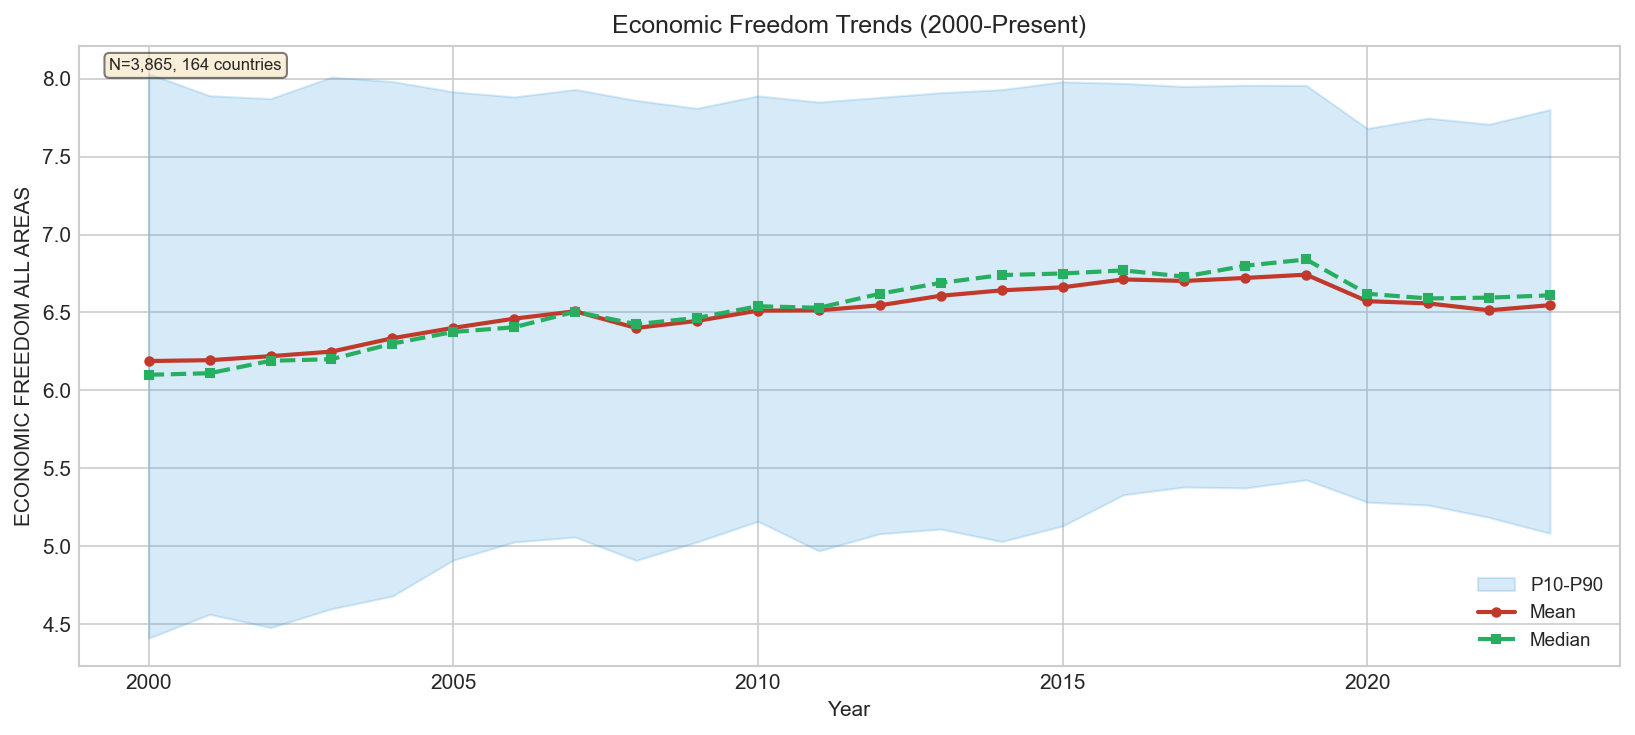

In [10]:
print("\n" + "=" * 60)
print("TIME TRENDS")
print("=" * 60)

# EFW overall trend
fig = plots.plot_time_trend(
    df_analysis, EFW_COL, 
    title=f'Economic Freedom Trends ({START_YEAR}-Present)',
    sample_label=f'N={len(df_analysis):,}, {df_analysis["iso3"].nunique()} countries'
)
plots.savefig(fig, 'annual_efw_trend.png')
plt.show()

Saved: outputs/figures/annual_efw_areas.png


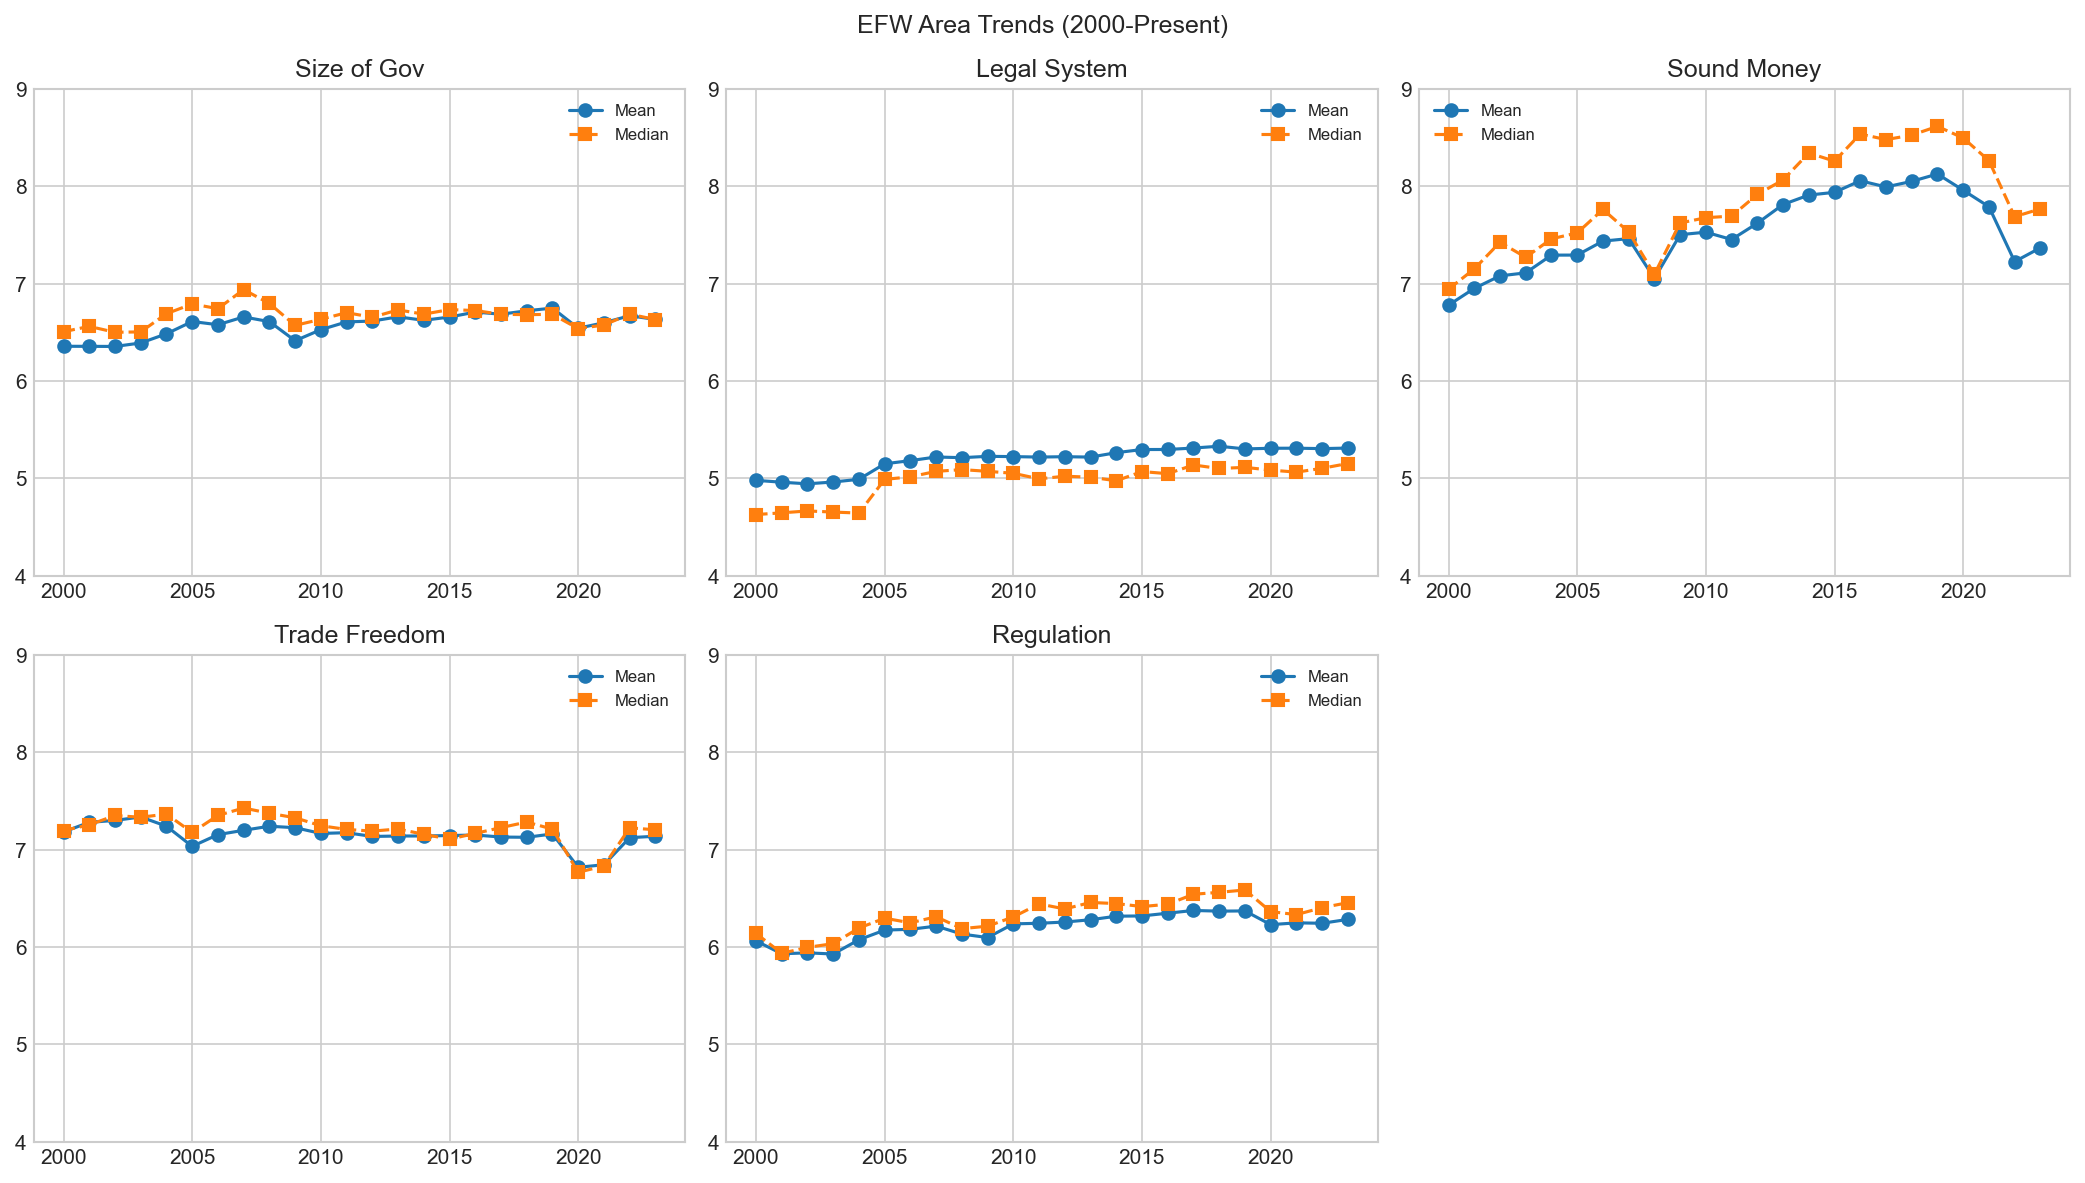

In [11]:
# EFW area trends
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

area_cols_present = [c for c in AREA_COLS if c in df_analysis.columns]
for i, (col, label) in enumerate(zip(area_cols_present, AREA_LABELS)):
    ax = axes[i]
    yearly = df_analysis.groupby('year')[col].agg(['mean', 'median'])
    ax.plot(yearly.index, yearly['mean'], 'o-', label='Mean')
    ax.plot(yearly.index, yearly['median'], 's--', label='Median')
    ax.set_title(label)
    ax.set_ylim(4, 9)
    ax.legend(fontsize=8)

axes[-1].axis('off')  # Hide extra subplot
plt.suptitle(f'EFW Area Trends ({START_YEAR}-Present)', fontsize=12)
plt.tight_layout()
plots.savefig(plt.gcf(), 'annual_efw_areas.png')
plt.show()

### 5.2 Macro Trends

Saved: outputs/figures/annual_macro_trends.png


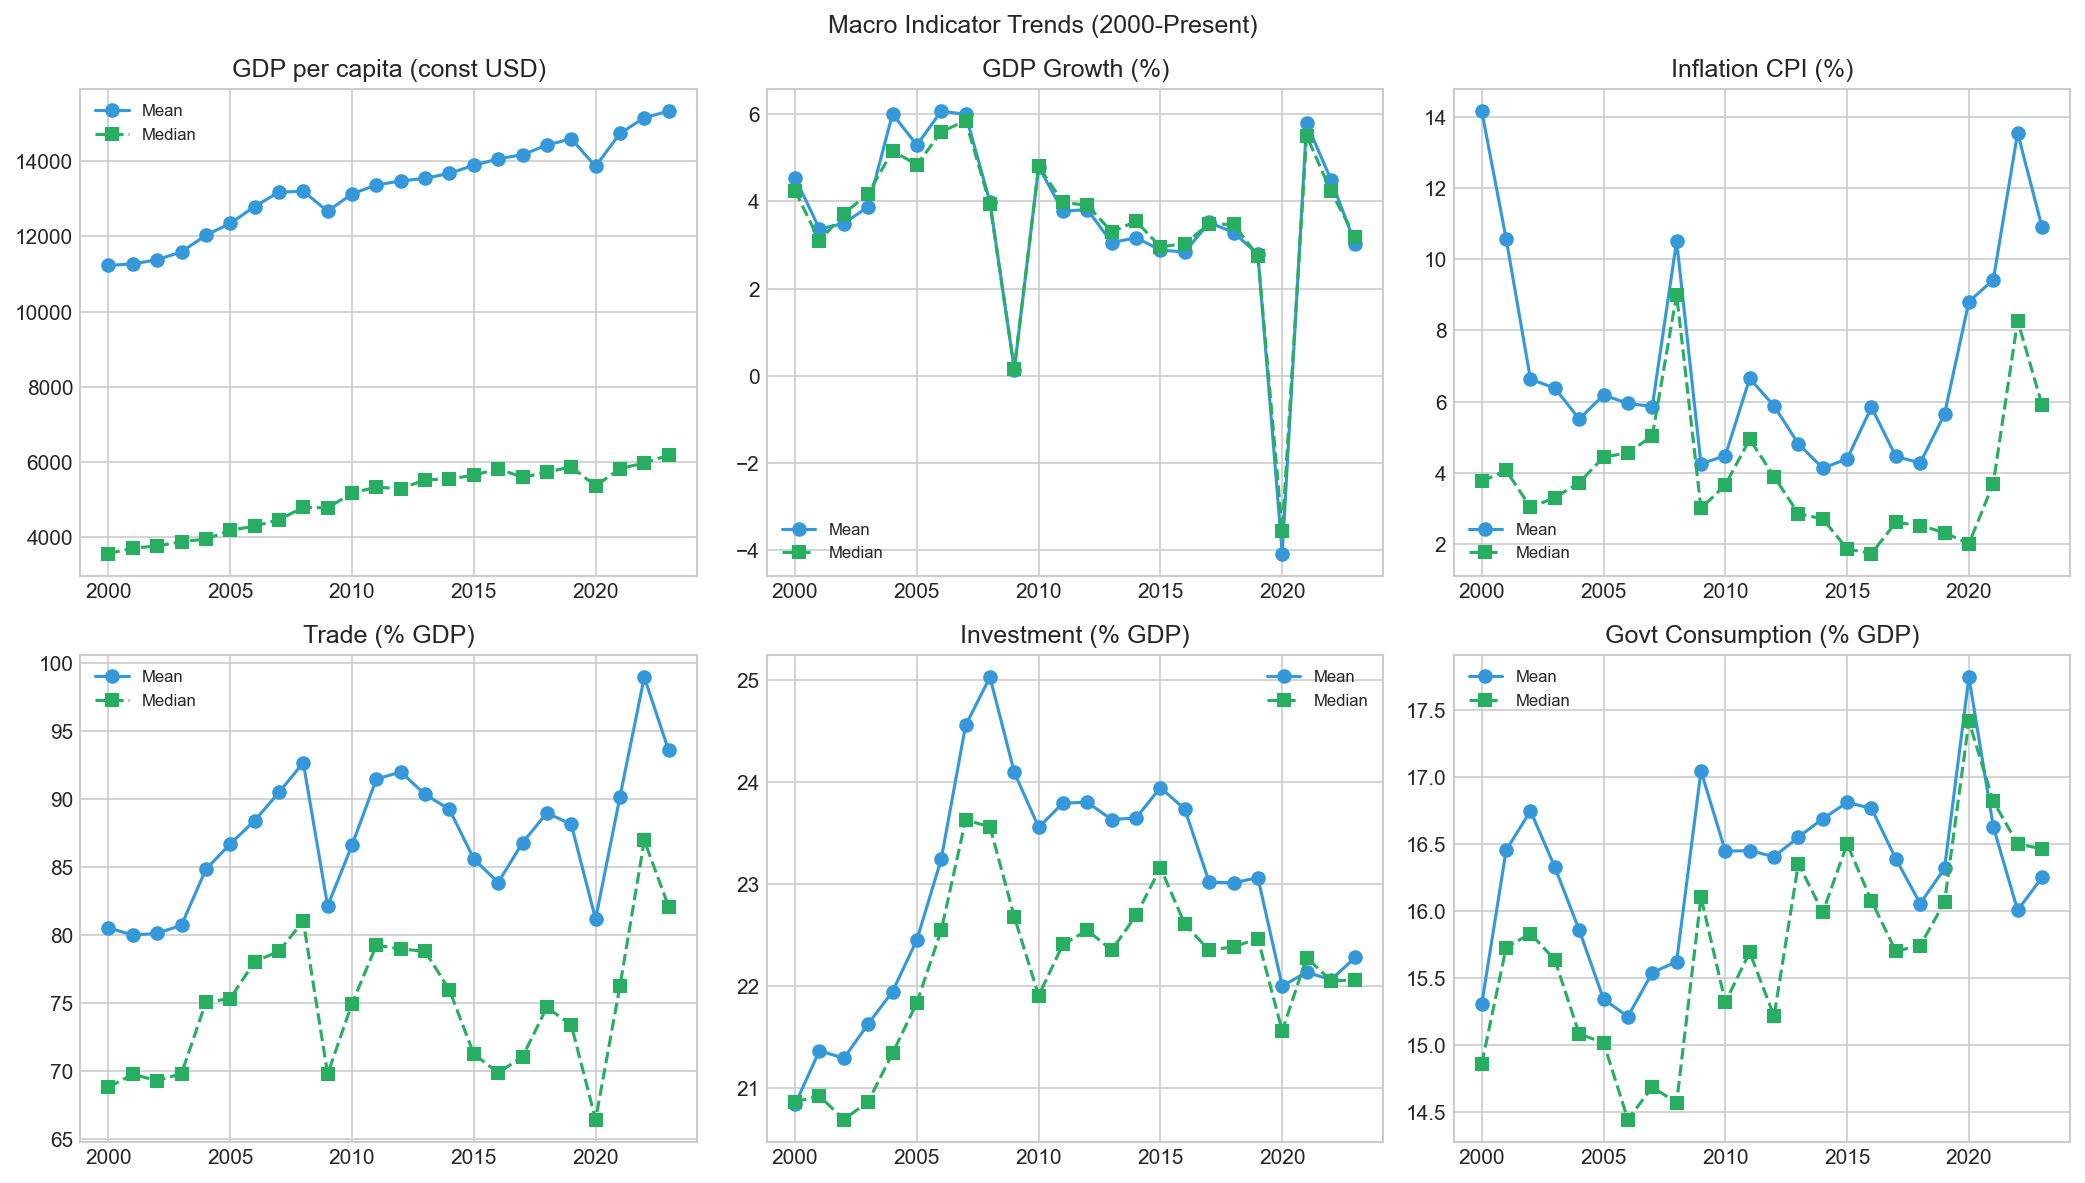

In [12]:
# Key macro trends
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

macro_labels = {
    'gdppc_filled': 'GDP per capita (WDI/PWT scaled)',
    'NY.GDP.MKTP.KD.ZG': 'GDP Growth (%)',
    'FP.CPI.TOTL.ZG': 'Inflation CPI (%)',
    'trade_openness_filled': 'Trade (% GDP)',
    'investment_gfcf_filled': 'Investment (% GDP)',
    'govt_consumption_filled': 'Govt Consumption (% GDP)'
}

for i, col in enumerate(CORE_MACRO):
    if col not in df_analysis.columns:
        continue
    ax = axes[i]
    yearly = df_analysis.groupby('year')[col].agg(['mean', 'median'])
    ax.plot(yearly.index, yearly['mean'], 'o-', color='#3498db', label='Mean')
    ax.plot(yearly.index, yearly['median'], 's--', color='#27ae60', label='Median')
    ax.set_title(macro_labels.get(col, col[:20]))
    ax.legend(fontsize=8)

plt.suptitle(f'Macro Indicator Trends ({START_YEAR}-Present)', fontsize=12)
plt.tight_layout()
plots.savefig(plt.gcf(), 'annual_macro_trends.png')
plt.show()

## 6. Correlations and Associations
### 6.1 Correlation Matrix


CORRELATIONS


Saved: outputs/figures/annual_correlation_matrix.png


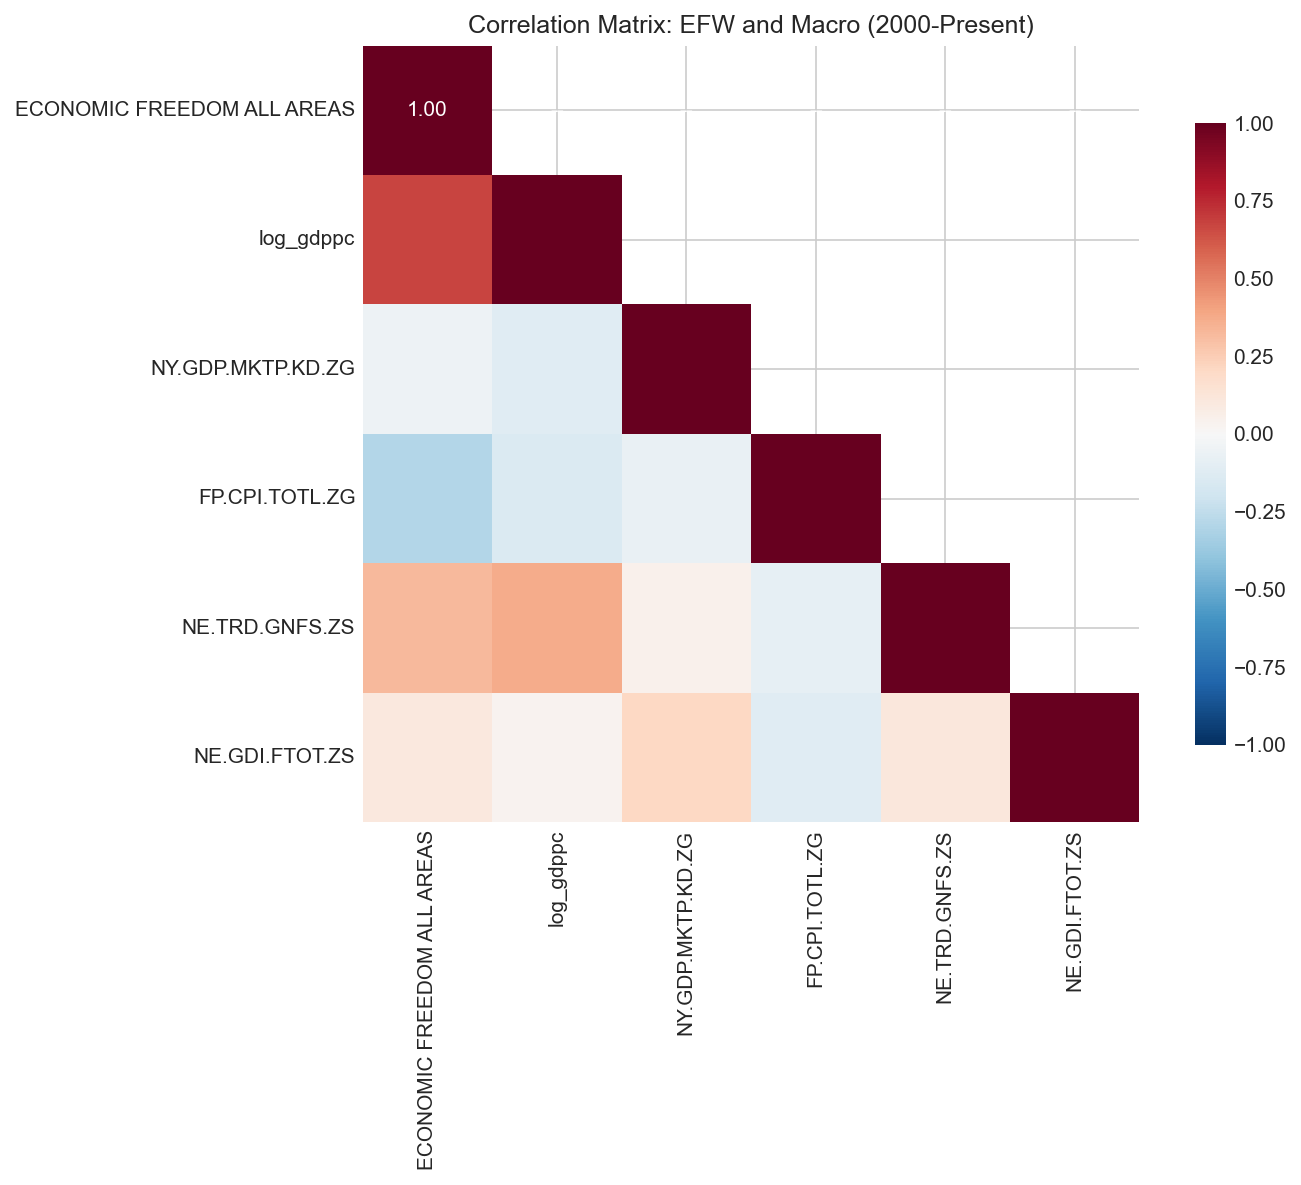


Correlations with EFW Overall:
  log_gdppc                     : +0.680
  NY.GDP.MKTP.KD.ZG             : -0.052
  FP.CPI.TOTL.ZG                : -0.294
  NE.TRD.GNFS.ZS                : +0.323
  NE.GDI.FTOT.ZS                : +0.109


In [13]:
print("\n" + "=" * 60)
print("CORRELATIONS")
print("=" * 60)

# Create log GDP per capita
if 'gdppc_filled' in df_analysis.columns:
    df_analysis['log_gdppc'] = np.log(df_analysis['gdppc_filled'].replace(0, np.nan))

# Correlation matrix
corr_cols = [EFW_COL, 'log_gdppc', 'NY.GDP.MKTP.KD.ZG', 'FP.CPI.TOTL.ZG',
             'trade_openness_filled', 'investment_gfcf_filled']
corr_cols = [c for c in corr_cols if c in df_analysis.columns]

fig = plots.plot_correlation_matrix(
    df_analysis, corr_cols,
    title=f'Correlation Matrix: EFW and Macro ({START_YEAR}-Present)'
)
plots.savefig(fig, 'annual_correlation_matrix.png')
plt.show()

# Print correlations with EFW
print("\nCorrelations with EFW Overall:")
for col in corr_cols:
    if col != EFW_COL and col in df_analysis.columns:
        corr = df_analysis[[EFW_COL, col]].dropna().corr().iloc[0, 1]
        print(f"  {col[:30]:30s}: {corr:+.3f}")

### 6.2 Key Scatter Plots

Saved: outputs/figures/annual_scatter_efw_gdp.png


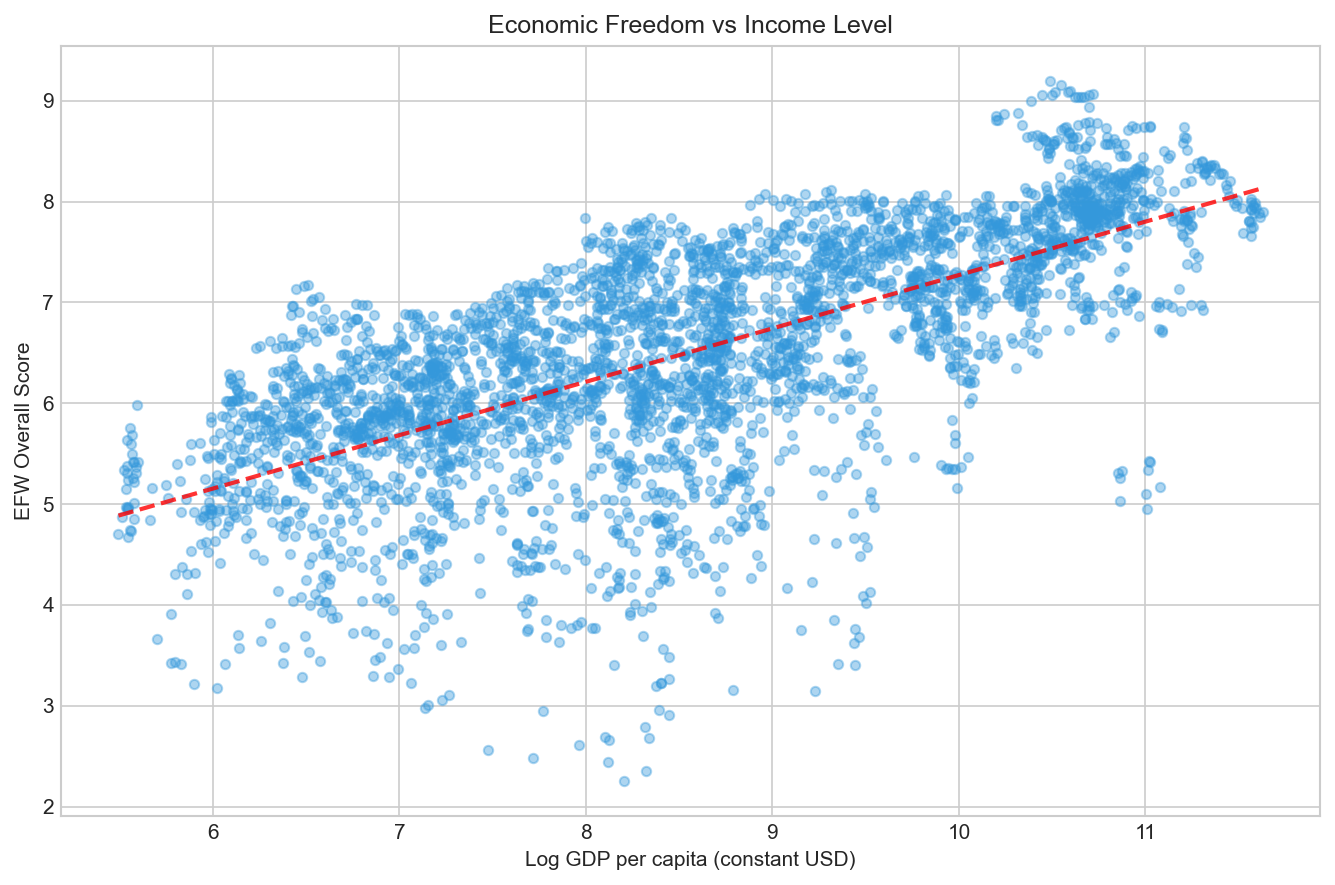

In [14]:
# EFW vs Log GDP per capita
if 'log_gdppc' in df_analysis.columns:
    fig = plots.plot_scatter(
        df_analysis, 'log_gdppc', EFW_COL,
        title='Economic Freedom vs Income Level',
        add_trend=True
    )
    plt.xlabel('Log GDP per capita (constant USD)')
    plt.ylabel('EFW Overall Score')
    plots.savefig(fig, 'annual_scatter_efw_gdp.png')
    plt.show()

Saved: outputs/figures/annual_scatter_efw_inflation.png


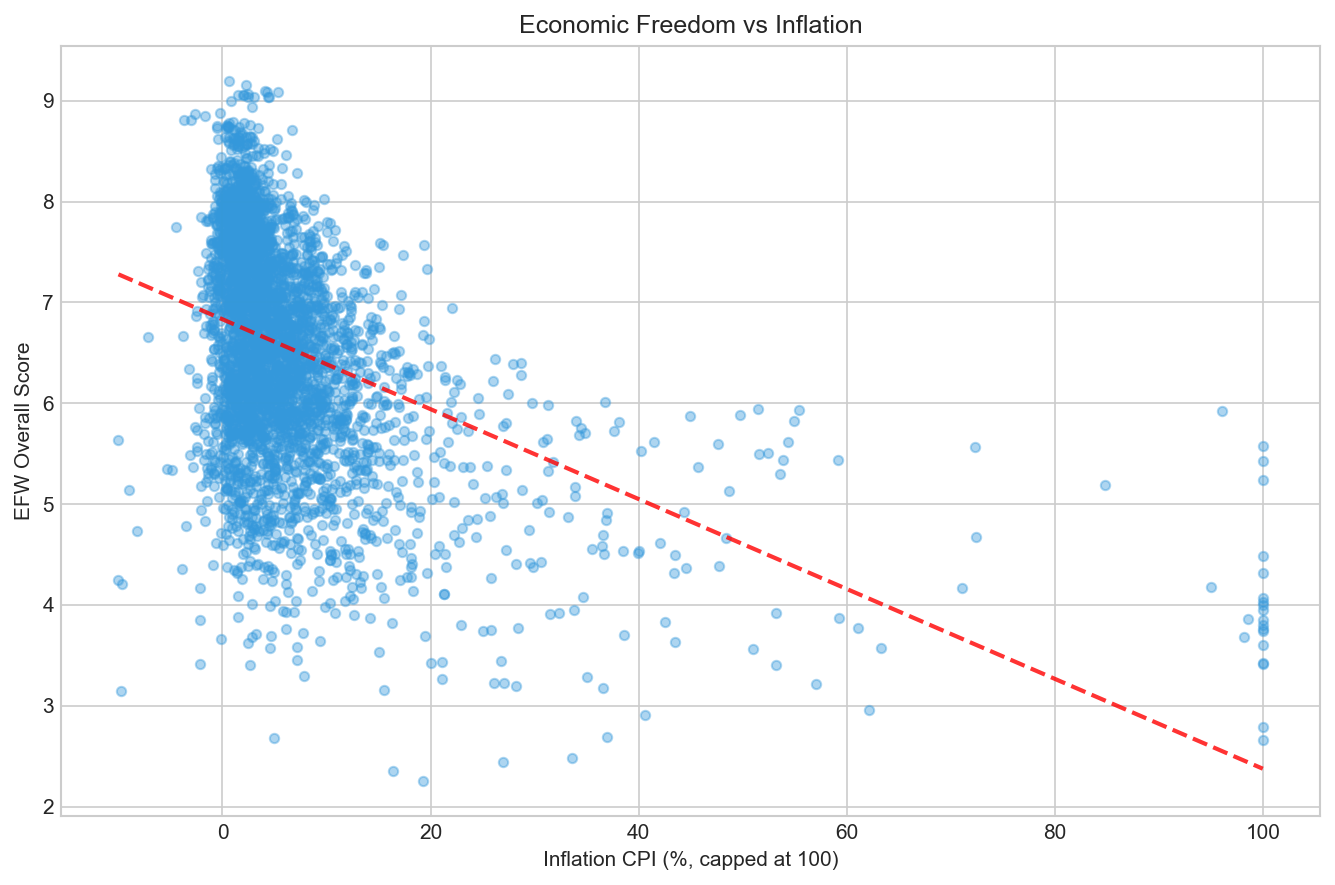

In [15]:
# EFW vs Inflation
if 'FP.CPI.TOTL.ZG' in df_analysis.columns:
    # Cap extreme inflation for visualization
    df_plot = df_analysis.copy()
    df_plot['inflation_capped'] = df_plot['FP.CPI.TOTL.ZG'].clip(-10, 100)
    
    fig = plots.plot_scatter(
        df_plot, 'inflation_capped', EFW_COL,
        title='Economic Freedom vs Inflation',
        add_trend=True
    )
    plt.xlabel('Inflation CPI (%, capped at 100)')
    plt.ylabel('EFW Overall Score')
    plots.savefig(fig, 'annual_scatter_efw_inflation.png')
    plt.show()

Saved: outputs/figures/annual_scatter_trade.png


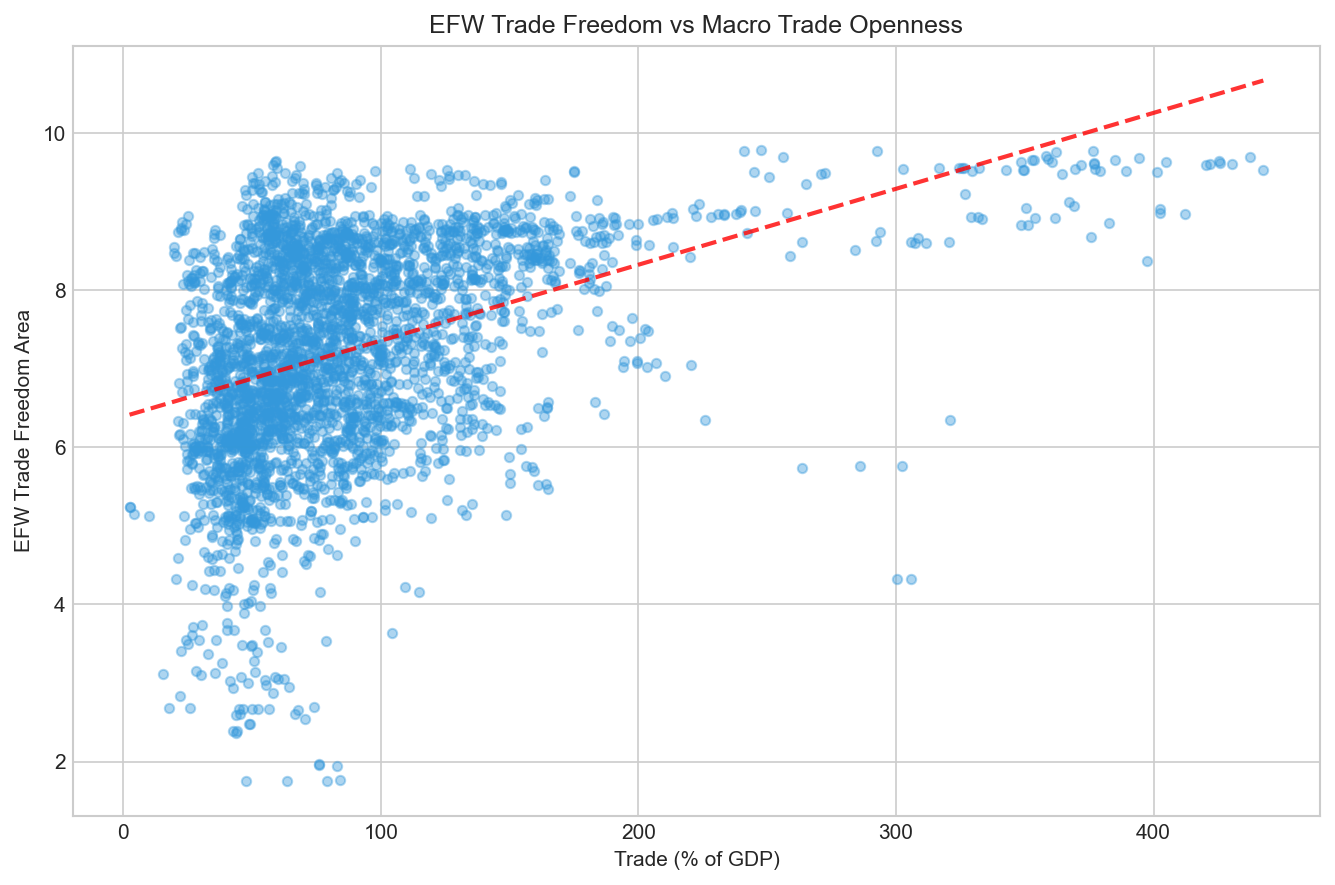

In [16]:
# Trade area vs Trade openness
trade_area = 'Area 4 Freedom to trade internationally'
if trade_area in df_analysis.columns and 'trade_openness_filled' in df_analysis.columns:
    fig = plots.plot_scatter(
        df_analysis, 'trade_openness_filled', trade_area,
        title='EFW Trade Freedom vs Macro Trade Openness',
        add_trend=True
    )
    plt.xlabel('Trade (% of GDP)')
    plt.ylabel('EFW Trade Freedom Area')
    plots.savefig(fig, 'annual_scatter_trade.png')
    plt.show()

## 7. Within-Country Changes

In [17]:
print("\n" + "=" * 60)
print("WITHIN-COUNTRY CHANGES")
print("=" * 60)

# Compute 5-year changes
df_sorted = df_analysis.sort_values(['iso3', 'year'])
df_sorted['efw_lag5'] = df_sorted.groupby('iso3')[EFW_COL].shift(5)
df_sorted['efw_change5'] = df_sorted[EFW_COL] - df_sorted['efw_lag5']

if 'NY.GDP.MKTP.KD.ZG' in df_sorted.columns:
    # Average growth over 5 years
    df_sorted['growth_avg5'] = df_sorted.groupby('iso3')['NY.GDP.MKTP.KD.ZG'].transform(
        lambda x: x.rolling(5, min_periods=3).mean()
    )

# Filter to rows with valid changes
df_changes = df_sorted[df_sorted['efw_change5'].notna()].copy()
print(f"Observations with 5-year EFW changes: {len(df_changes):,}")


WITHIN-COUNTRY CHANGES
Observations with 5-year EFW changes: 3,045


Saved: outputs/figures/annual_change_efw_growth.png


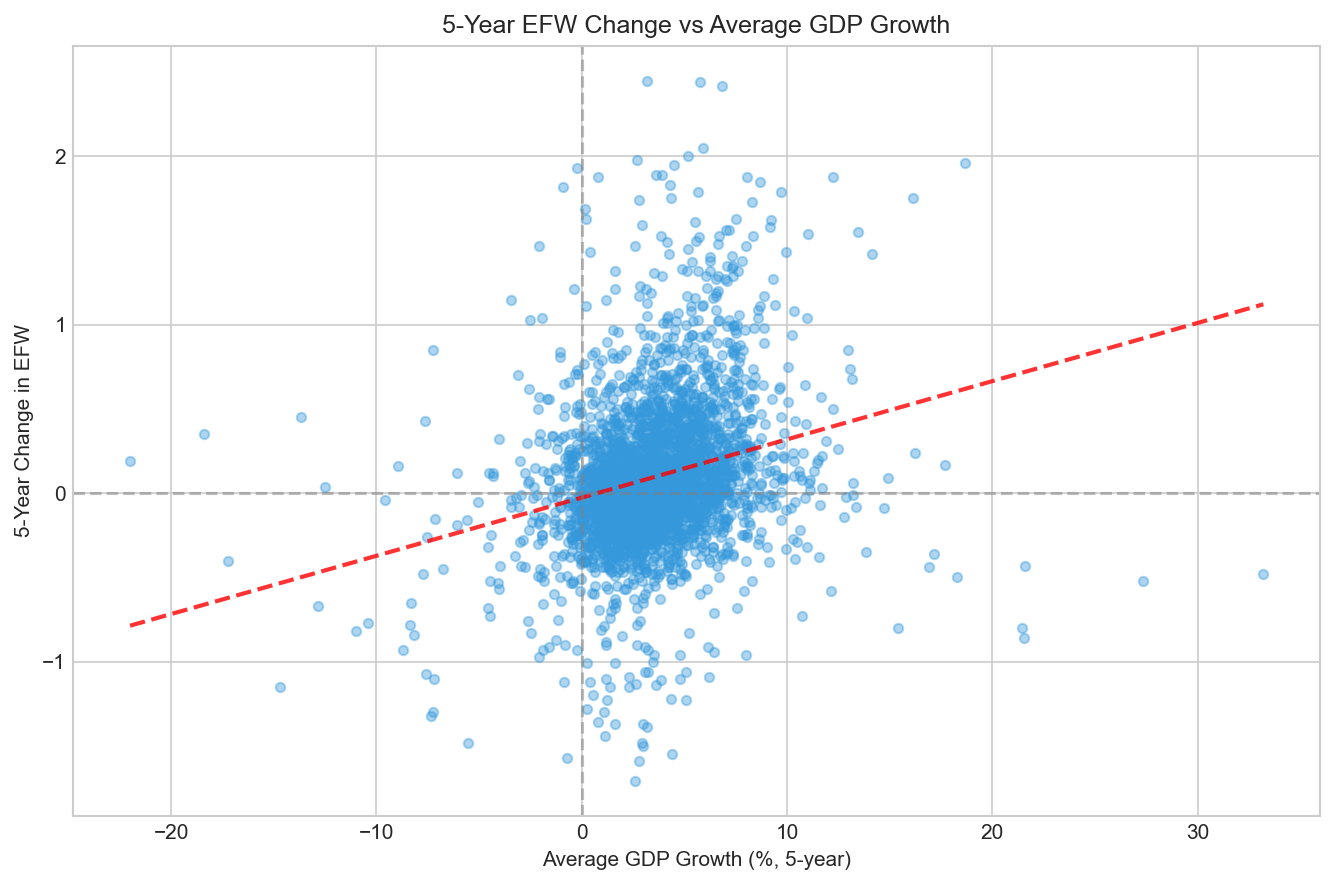

Correlation (ΔEFW vs Avg Growth): +0.250


In [18]:
# Plot: EFW change vs GDP growth
if 'growth_avg5' in df_changes.columns:
    fig = plots.plot_scatter(
        df_changes, 'growth_avg5', 'efw_change5',
        title='5-Year EFW Change vs Average GDP Growth',
        add_trend=True
    )
    plt.xlabel('Average GDP Growth (%, 5-year)')
    plt.ylabel('5-Year Change in EFW')
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    plots.savefig(fig, 'annual_change_efw_growth.png')
    plt.show()
    
    # Correlation
    corr = df_changes[['efw_change5', 'growth_avg5']].dropna().corr().iloc[0, 1]
    print(f"Correlation (ΔEFW vs Avg Growth): {corr:+.3f}")

## 8. Outliers and Extreme Regimes

In [19]:
print("\n" + "=" * 60)
print("OUTLIERS AND EXTREME REGIMES")
print("=" * 60)

# High inflation episodes
if 'FP.CPI.TOTL.ZG' in df_analysis.columns:
    high_inflation = df_analysis[df_analysis['FP.CPI.TOTL.ZG'] > 50].copy()
    if len(high_inflation) > 0:
        print(f"\nHigh inflation episodes (CPI > 50%): {len(high_inflation)}")
        high_inf_summary = high_inflation.groupby('iso3').agg({
            'year': ['min', 'max', 'count'],
            'FP.CPI.TOTL.ZG': 'max',
            EFW_COL: 'mean'
        })
        high_inf_summary.columns = ['year_min', 'year_max', 'n_years', 'max_inflation', 'mean_efw']
        print(high_inf_summary.sort_values('max_inflation', ascending=False).head(10))
        quality.save_table(high_inf_summary.reset_index(), 'high_inflation_episodes')


OUTLIERS AND EXTREME REGIMES

High inflation episodes (CPI > 50%): 43
      year_min  year_max  n_years  max_inflation  mean_efw
iso3                                                      
ZWE       2019      2022        4     557.201817  3.945000
COD       2000      2001        2     513.906844  3.415000
SDN       2018      2022        5     359.093041  3.836000
AGO       2000      2003        4     324.996872  3.757500
VEN       2014      2016        3     254.948535  2.803333
LBN       2020      2023        4     221.341644  5.360000
BLR       2000      2012        4     168.620236  3.840000
ARG       2019      2023        3     133.488936  4.816667
ECU       2000      2000        1      96.096376  5.920000
SRB       2000      2001        2      95.005226  4.175000
Saved: outputs/tables/high_inflation_episodes.csv


In [20]:
# Growth collapses
if 'NY.GDP.MKTP.KD.ZG' in df_analysis.columns:
    growth_collapse = df_analysis[df_analysis['NY.GDP.MKTP.KD.ZG'] < -10].copy()
    if len(growth_collapse) > 0:
        print(f"\nGrowth collapses (GDP growth < -10%): {len(growth_collapse)}")
        collapse_summary = growth_collapse.groupby('iso3').agg({
            'year': 'count',
            'NY.GDP.MKTP.KD.ZG': 'min',
            EFW_COL: 'mean'
        })
        collapse_summary.columns = ['n_episodes', 'worst_growth', 'mean_efw']
        print(collapse_summary.sort_values('worst_growth').head(10))
        quality.save_table(collapse_summary.reset_index(), 'growth_collapse_episodes')


Growth collapses (GDP growth < -10%): 52
      n_episodes  worst_growth  mean_efw
iso3                                    
LBY            5    -50.338515  4.220000
IRQ            2    -36.656780  4.070000
CAF            1    -36.391977  5.050000
LBR            1    -30.145133  4.450000
VEN            5    -29.998570  2.752000
SDN            2    -29.433272  4.275000
UKR            3    -28.758584  5.250000
YEM            2    -27.994546  5.495000
SYR            3    -26.339017  4.486667
LBN            1    -21.399900  5.190000
Saved: outputs/tables/growth_collapse_episodes.csv


## 9. Missingness Dashboard

In [21]:
# Missingness by variable
print("\n" + "=" * 60)
print("MISSINGNESS ANALYSIS")
print("=" * 60)

miss_table = quality.compute_missingness_table(df_merged, all_analysis_cols)
print(miss_table.to_string(index=False))
quality.save_table(miss_table, 'missingness_annual')


MISSINGNESS ANALYSIS
                                                       variable  n_present  n_missing  pct_missing  coverage_pct
                                     ECONOMIC FREEDOM ALL AREAS       3889       1560    28.629106     71.370894
                                      Area 1 Size of Government       3926       1523    27.950083     72.049917
Area 2 Legal System & Property Rights -- With Gender Adjustment       3903       1546    28.372178     71.627822
                                             Area 3 Sound Money       3940       1509    27.693155     72.306845
                        Area 4 Freedom to trade internationally       3585       1864    34.208112     65.791888
                                              Area 5 Regulation       3960       1489    27.326115     72.673885
                                                 NY.GDP.PCAP.KD       5151        298     5.468893     94.531107
                                              NY.GDP.MKTP.KD.ZG       5160

Saved: outputs/figures/annual_missingness_heatmap.png


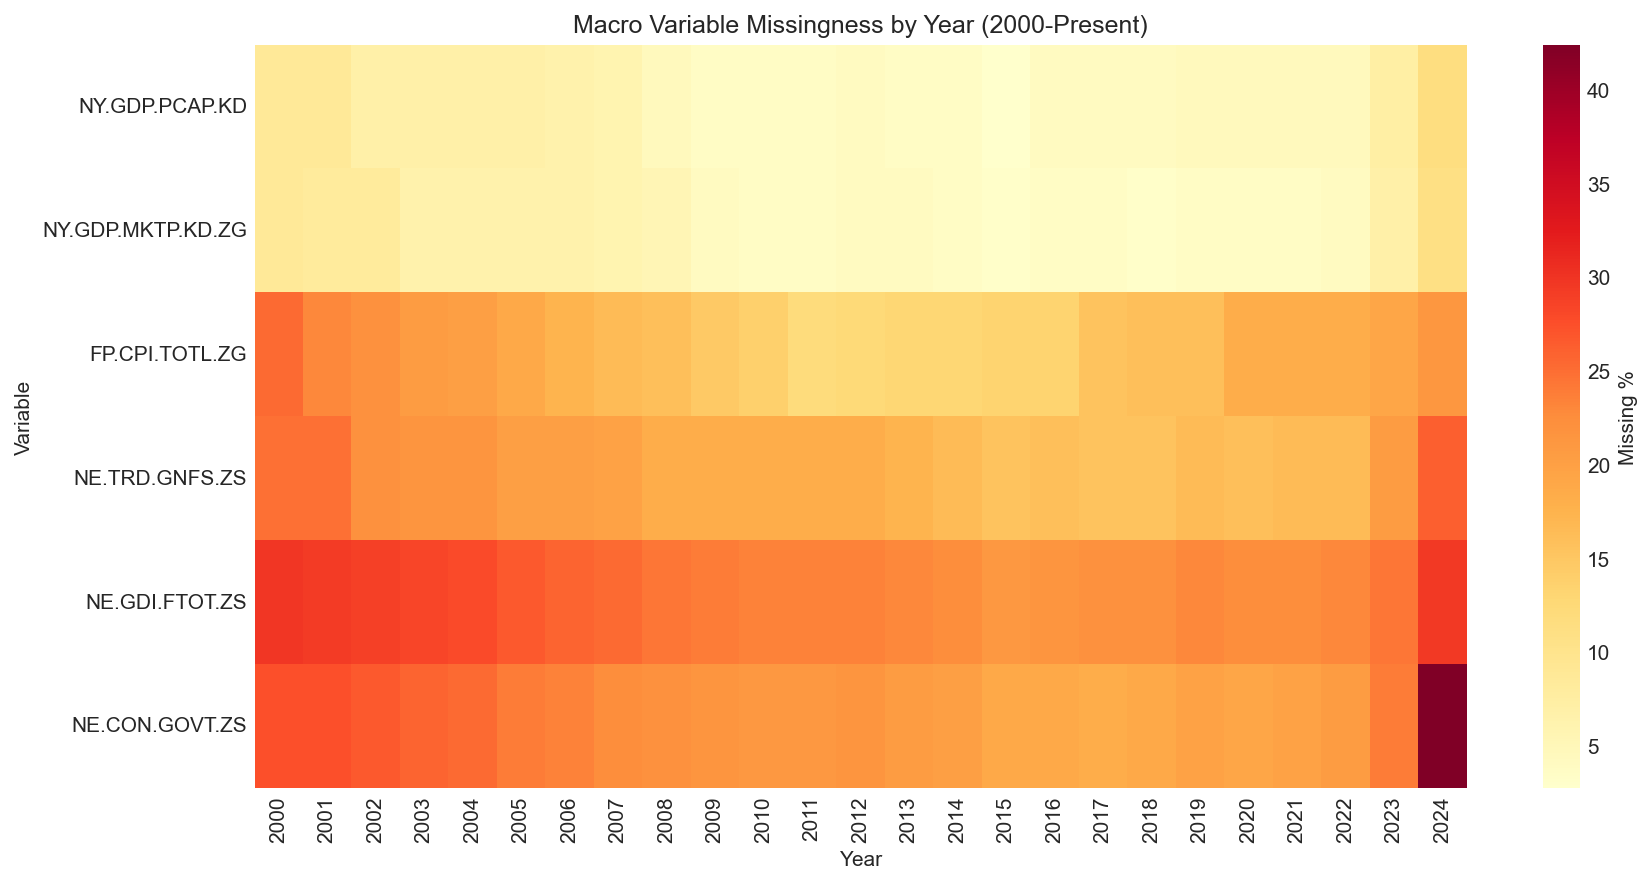

In [22]:
# Missingness heatmap
fig = plots.plot_missingness_heatmap(
    df_merged, 
    CORE_MACRO,
    title=f'Macro Variable Missingness by Year ({START_YEAR}-Present)'
)
plots.savefig(fig, 'annual_missingness_heatmap.png')
plt.show()

## 10. Summary

In [23]:
print("\n" + "=" * 70)
print("ANNUAL EDA COMPLETE")
print("=" * 70)

efw_gdppc_corr = df_analysis[[EFW_COL, 'log_gdppc']].dropna().corr().iloc[0,1] if 'log_gdppc' in df_analysis.columns else float('nan')

print(f"""
Analysis Period: {START_YEAR}-{df_analysis['year'].max()}
Primary Sample: {len(df_analysis):,} country-year observations
Countries: {df_analysis['iso3'].nunique()}

Key Findings:
- EFW overall mean: {df_analysis[EFW_COL].mean():.2f} (SD: {df_analysis[EFW_COL].std():.2f})
- Correlation EFW vs Log GDP/capita: {efw_gdppc_corr:.3f}

Outputs saved to:
- Figures: outputs/figures/
- Tables: outputs/tables/
""")


ANNUAL EDA COMPLETE

Analysis Period: 2000-2023
Primary Sample: 3,865 country-year observations
Countries: 164

Key Findings:
- EFW overall mean: 6.50 (SD: 1.14)
- Correlation EFW vs Log GDP/capita: 0.680

Outputs saved to:
- Figures: outputs/figures/
- Tables: outputs/tables/

